In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os
import os, sys
import torch
import numpy as np

In [2]:
    
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, maxDomain_0, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    maxDomain[0] = maxDomain_0
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    # print(f"dx = {dx}, dy = {dy}, h = {h}")
    # print(f"nx = {nx}, ny = {ny}")
    # print(f"minDomain = {minDomain}, maxDomain = {maxDomain}")
    # print(f"periodicity = {periodicity}")
    # print(f"dim = {dim}")
    # print(f"device = {device}")
    # print(f"maxDomain_0 = {maxDomain_0}")
    # print(f"targetNumNeighbors = {targetNumNeighbors}")
    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    ypositions = []
    for d in range(dim):
        ypositions.append(torch.linspace(-0.5 + dy / 2, 0.5 - dy / 2, ny, device = device))
    grid = torch.meshgrid(*ypositions, indexing = 'xy')
    y = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    ySupport = torch.ones(y.shape[0], device = device) * volumeToSupport(dy**dim, targetNumNeighbors, dim)
    return (positions, positions), (supports, supports), (minDomain, maxDomain), periodicity, positions.shape[0], dx

    randomAngles = torch.rand(nx * ny, dim - 1, device = device) * 2 * np.pi
    randomRadii = (torch.randn(nx * ny, device = device) * 0.5 * shortExtent).abs()
    randomOffsets = torch.zeros((nx * ny, dim), device = device)
    randomPositions = torch.zeros((nx * ny, dim), device = device)
    for d in range(dim - 1):
        randomOffsets[:, d] = torch.cos(randomAngles[:, d]) * randomRadii
    randomOffsets[:, dim - 1] = torch.sin(randomAngles[:, dim - 2]) * randomRadii
        
    randomOffsets.clamp(minDomain.min().item(), maxDomain.max().item())
    
    supports = torch.ones((nx * ny,), device = device) * h * 4
    
    minRadius = torch.min(randomRadii)
    maxRadius = torch.max(randomRadii)
    print(f"minRadius = {minRadius}, maxRadius = {maxRadius}")
    
    supportFactor = 8
    
    # rescale support such that at min radius the support is h / factor and h at the max radius
    
    supports = supports * (1 + (randomRadii - minRadius) / (maxRadius - minRadius) * (supportFactor - 1)) / supportFactor
    
    return (randomOffsets, randomOffsets), (supports, supports), (minDomain, maxDomain), periodicity, randomPositions.shape[0]

    


In [3]:
from radius_util import *

In [4]:

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
targetNumNeighbors = 50
hashMapLength = 4096
nx = 32
dim = 2
periodic = False
(y, x), (ySupport, xSupport), (minDomain, maxDomain), periodicity, hashMapLength, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, 1.0, False, device)
h = ySupport[0].cpu().item()

# from torchCompactRadius.util import DomainDescription, PointCloud

minDomain *= 2
maxDomain *= 2
domainDescription = DomainDescription(minDomain, maxDomain, periodicity, dim)

pointCloudX = PointCloud(x, xSupport)
pointCloudY = PointCloud(y, ySupport)

# pointCloudX = PointCloud(x, None)
# pointCloudY = PointCloud(y, None)

[X] Min Supports: 0.24933892488479614, Max Supports: 0.24933892488479614
[Y] Min Supports: 0.24933892488479614, Max Supports: 0.24933892488479614


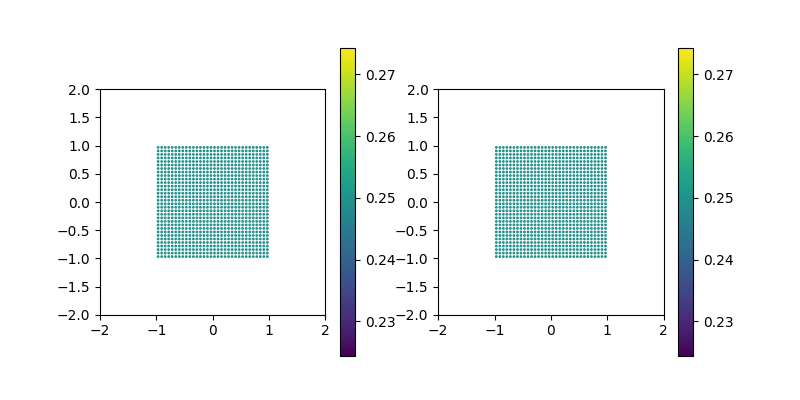

In [5]:
pointCloudX.supports = xSupport #+ torch.randn_like(xSupport) * xSupport.max() / 16 + (1 - torch.linalg.norm(x, dim = -1))**2 * xSupport.max() * 8
pointCloudY.supports = ySupport #+ torch.randn_like(ySupport) * ySupport.max() / 16 + (1 - torch.linalg.norm(y, dim = -1))**2 * xSupport.min() * 4 - 0.125

pointCloudX.supports = pointCloudX.supports.clamp(max = (domainDescription.max - domainDescription.min).min() / 4 -1e-3)
pointCloudY.supports = pointCloudY.supports.clamp(max = (domainDescription.max - domainDescription.min).min() / 4 -1e-3)

import matplotlib.pyplot as plt
fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)

sc = axis[0,0].scatter(y[:,0].cpu(), y[:,1].cpu(), s = 1, c = pointCloudY.supports.cpu().numpy())
fig.colorbar(sc, ax = axis[0,0])
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,0].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = pointCloudX.supports.cpu().numpy())
fig.colorbar(sc, ax = axis[0,1])
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,1].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())

print(f'[X] Min Supports: {pointCloudX.supports.min()}, Max Supports: {pointCloudX.supports.max()}')
print(f'[Y] Min Supports: {pointCloudY.supports.min()}, Max Supports: {pointCloudY.supports.max()}')


In [6]:
from typing import Optional, List
import torch

@torch.jit.script
def mod(x, min : float, max : float):
    return torch.where(torch.abs(x) > (max - min) / 2, torch.sgn(x) * ((torch.abs(x) + min) % (max - min) + min), x)
    
@torch.jit.script
def radiusNaive(x, y, hx, hy, periodic : Optional[torch.Tensor] = None, minDomain = None, maxDomain = None, mode : str = 'gather'):
    periodicity = torch.tensor([False] * x.shape[1], dtype = torch.bool, device = x.device) if periodic is None else periodic
    
    pos_x = torch.stack([x[:,i] if not periodic_i else torch.remainder(x[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    pos_y = torch.stack([y[:,i] if not periodic_i else torch.remainder(y[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    
    distanceMatrices = torch.stack([pos_x[:,i] - pos_y[:,i,None] if not periodic_i else mod(pos_x[:,i] - pos_y[:,i,None], minDomain[i], maxDomain[i]) for i, periodic_i in enumerate(periodicity)], dim = -1)
    distanceMatrix = torch.sqrt(torch.sum(distanceMatrices**2, dim = -1))
    
    indexI, indexJ = torch.meshgrid(torch.arange(x.shape[0]).to(x.device), torch.arange(y.shape[0]).to(y.device), indexing = 'xy')
    if mode == 'gather':        
        gatherMatrix = hx.repeat(y.shape[0],1)
        adjacencyDense = distanceMatrix <= gatherMatrix
        # supports = gatherMatrix[adjacencyDense]
    elif mode == 'scatter':        
        scatterMatrix = hy.repeat(x.shape[0],1).mT
        adjacencyDense = distanceMatrix <= scatterMatrix
        # supports = scatterMatrix[adjacencyDense]
    elif mode == 'symmetric':
        symmetricMatrix = (hx + hy[:,None]) / 2
        adjacencyDense = distanceMatrix <= symmetricMatrix
    elif mode == 'superSymmetric':
        hxMatrix = hx.repeat(y.shape[0],1)
        hyMatrix = hy.repeat(x.shape[0],1).mT
        symmetricMatrix = torch.maximum(hxMatrix, hyMatrix)
        adjacencyDense = distanceMatrix <= symmetricMatrix
    else:
        raise ValueError('mode must be one of gather, scatter, symmetric, or superSymmetric')
        # supports = symmetricMatrix[adjacencyDense]
    
    ii = indexI[adjacencyDense]
    jj = indexJ[adjacencyDense]

    return ii, jj#, distanceMatrix[adjacencyDense], distanceMatrices[adjacencyDense], supports

@torch.jit.script
def radiusNaiveFixed(x, y, h : torch.Tensor, periodic : Optional[torch.Tensor] = None, minDomain = None, maxDomain = None):
    periodicity = torch.tensor([False] * x.shape[1], dtype = torch.bool, device = x.device) if periodic is None else periodic
    
    pos_x = torch.stack([x[:,i] if not periodic_i else torch.remainder(x[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    pos_y = torch.stack([y[:,i] if not periodic_i else torch.remainder(y[:,i] - minDomain[i], maxDomain[i] - minDomain[i]) + minDomain[i] for i, periodic_i in enumerate(periodicity)], dim = 1)
    
    distanceMatrices = torch.stack([pos_x[:,i] - pos_y[:,i,None] if not periodic_i else mod(pos_x[:,i] - pos_y[:,i,None], minDomain[i], maxDomain[i]) for i, periodic_i in enumerate(periodicity)], dim = -1)
    distanceMatrix = torch.sum(distanceMatrices**2, dim = -1)
    
    indexI, indexJ = torch.meshgrid(torch.arange(x.shape[0]).to(x.device), torch.arange(y.shape[0]).to(y.device), indexing = 'xy')
    adjacencyDense = distanceMatrix <= h**2
    
    ii = indexI[adjacencyDense]
    jj = indexJ[adjacencyDense]

    return ii, jj#, distanceMatrix[adjacencyDense], distanceMatrices[adjacencyDense], supports

In [7]:
i,j = radiusNaive(x, y, pointCloudX.supports, pointCloudY.supports, periodicity, domainDescription.min, domainDescription.max, mode = 'superSymmetric')

In [8]:
ii, ni_ = torch.unique(i, return_counts = True)
ni = torch.zeros(x.shape[0], dtype = torch.int64, device = x.device)
ni[ii] = ni_
jj, nj_ = torch.unique(j, return_counts = True)
nj = torch.zeros(y.shape[0], dtype = torch.int64, device = x.device)
nj[jj] = nj_

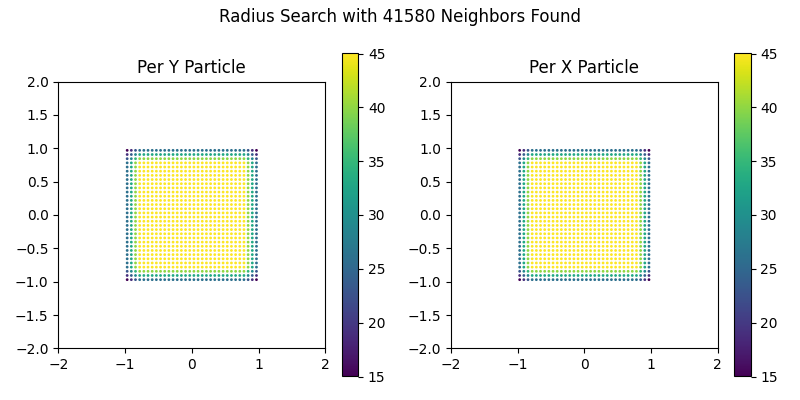

In [9]:
fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)
sc = axis[0,0].scatter(y[:,0].cpu(), y[:,1].cpu(), s = 1, c = nj.cpu().numpy())
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,0].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,0].set_title('Per Y Particle')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = ni.cpu().numpy())
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,1].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,1].set_title('Per X Particle')

fig.colorbar(sc, ax = axis[0,1])

fig.suptitle(f'Radius Search with {i.shape[0]} Neighbors Found')
fig.tight_layout()

In [10]:
# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/winchenbach/.cache/warp/1.12.0


In [11]:
from wp_math import *
from wp_util import *
from wp_radius_small import warp_radius_search_small


In [12]:

adjacency = warp_radius_search_small(
    x,  # Query points (torch tensor, Nx2)
    y,  # Reference points (torch tensor, Mx2)
    pointCloudX.supports,  # Query radii (torch tensor, N)
    pointCloudY.supports,  # Reference radii (torch tensor, M)
    periodicity,  # Periodicity flags (torch tensor, 2)
    domainDescription,
    mode='superSymmetric'  # Mode of radius comparison
)

print(f"GPU-direct Warp implementation found {adjacency.i.shape[0]} neighbors")
print(f'Num Rows: {adjacency.numRows}, Num Cols: {adjacency.numCols}')
print(f'Min Neighbors: {adjacency.numNeighbors.min()}, Max Neighbors: {adjacency.numNeighbors.max()}, Mean: {adjacency.numNeighbors.float().mean()}')
print(f'Min I: {adjacency.i.min()}, Min J: {adjacency.j.min()}')
print(f'Max I: {adjacency.i.max()}, Max J: {adjacency.j.max()}')

Module wp_radius_small 745fe77 load on device 'cpu' took 1.32 ms  (cached)
GPU-direct Warp implementation found 41580 neighbors
Num Rows: 1024, Num Cols: 1024
Min Neighbors: 15, Max Neighbors: 45, Mean: 40.60546875
Min I: 0, Min J: 0
Max I: 1023, Max J: 1023


In [13]:
i_torch = adjacency.i
j_torch = adjacency.j
print(f"GPU-direct Warp implementation found {i_torch.shape[0]} neighbors")
print(f"Torch implementation found {i.shape[0]} neighbors")
print(f"Results match: {torch.allclose(i.sort()[0], i_torch.sort()[0].to(i.dtype)) and torch.allclose(j.sort()[0], j_torch.sort()[0].to(j.dtype))}")
print(f"Output device: {i_torch.device}")

GPU-direct Warp implementation found 41580 neighbors
Torch implementation found 41580 neighbors
Results match: True
Output device: cpu


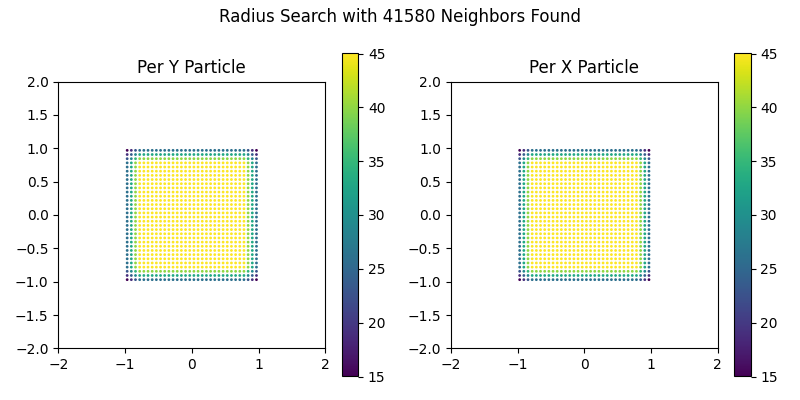

In [14]:
fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)
sc = axis[0,0].scatter(y[:,0].cpu(), y[:,1].cpu(), s = 1, c = nj.cpu().numpy())
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,0].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,0].set_title('Per Y Particle')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = adjacency.numNeighbors.cpu().numpy())
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,1].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,1].set_title('Per X Particle')

fig.colorbar(sc, ax = axis[0,1])

fig.suptitle(f'Radius Search with {i.shape[0]} Neighbors Found')
fig.tight_layout()

In [15]:
queryPositions = pointCloudX.positions
querySupports = pointCloudX.supports
referencePositions = pointCloudX.positions
referenceSupports = pointCloudX.supports
mode = 'gather'

In [16]:

x_warp = castTorchToWarp(queryPositions)
y_warp = castTorchToWarp(referencePositions)
hx_warp = castTorchToWarp(querySupports)
hy_warp = castTorchToWarp(referenceSupports)
periodic_warp = castTorchToWarp(periodicity)
min_domain_warp = castTorchToWarp(domainDescription.min)
max_domain_warp = castTorchToWarp(domainDescription.max)

# print("\nTesting castTorchToWarp function...")
# print('x_warp shape:', x_warp.shape, 'dtype:', x_warp.dtype, 'device:', x_warp.device)
# print('y_warp shape:', y_warp.shape, 'dtype:', y_warp.dtype, 'device:', y_warp.device)
# print('hx_warp shape:', hx_warp.shape, 'dtype:', hx_warp.dtype, 'device:', hx_warp.device)
# print('hy_warp shape:', hy_warp.shape, 'dtype:', hy_warp.dtype, 'device:', hy_warp.device)
# print('periodic_warp shape:', periodic_warp.shape, 'dtype:', periodic_warp.dtype, 'device:', periodic_warp.device)
# print('min_domain_warp shape:', min_domain_warp.shape, 'dtype:', min_domain_warp.dtype, 'device:', min_domain_warp.device)  


N = x_warp.shape[0]
M = y_warp.shape[0]
D = x_warp.shape[1]

# mode = 'gather'  # Change as needed: 'gather', 'scatter', 'symmetric', 'superSymmetric'

mode_map = {'gather': 0, 'scatter': 1, 'symmetric': 2, 'superSymmetric': 3}
mode_uint = mode_map.get(mode, 0)
    
edge_count = wp.zeros(N, dtype=wp.int32, device=x_warp.device)

In [17]:
from wp_compactHash import *

# Convert Warp arrays back to PyTorch tensors using wp.t\o_torch() for direct GPU access
from radius_util import AdjacencyList


In [18]:
domainDescription.periodic[:] = True

domain = DomainDescription(domainDescription.min.cpu(), domainDescription.max.cpu(), domainDescription.periodic.cpu(), domainDescription.dim)
domainHalf = DomainDescription(domainDescription.min.cpu() / 2, domainDescription.max.cpu() / 2, domainDescription.periodic.cpu(), domainDescription.dim)
domainDouble = DomainDescription(domainDescription.min.cpu() * 2, domainDescription.max.cpu() * 2, domainDescription.periodic.cpu(), domainDescription.dim)

chosenDomain = domain
domainLength = chosenDomain.max - chosenDomain.min
offset = 3 * domainLength


In [19]:
adjacencyCH = radiusSearchCompactHashMap(
    queryPositions, referencePositions + offset,
    querySupports, referenceSupports,
    periodicity = domainDescription.periodic, domainDescription=chosenDomain,
    mode = 'superSymmetric', hashMapLength=1024
)

adjacency = warp_radius_search_small(
    queryPositions, referencePositions + offset, querySupports, referenceSupports, periodicity, chosenDomain, mode = 'superSymmetric'
)

i,j = radiusNaive(queryPositions, referencePositions + offset, querySupports, referenceSupports, periodicity, chosenDomain.min, chosenDomain.max, mode = 'superSymmetric')

print(f'Torch implementation found {i.shape[0]} neighbors')

print(f'Compact Hash Implementation found {adjacencyCH.i.shape[0]} neighbors')
print(torch.allclose(torch.sort(adjacencyCH.i.cpu().to(i.dtype)).values, torch.sort(i.cpu()).values))
print(torch.allclose(torch.sort(adjacencyCH.j.cpu().to(j.dtype)).values, torch.sort(j.cpu()).values))

print(f"GPU-direct Warp implementation found {adjacency.i.shape[0]} neighbors")
print(torch.allclose(torch.sort(adjacency.i.cpu().to(i.dtype)).values, torch.sort(i.cpu()).values))
print(torch.allclose(torch.sort(adjacency.j.cpu().to(j.dtype)).values, torch.sort(j.cpu()).values))


Module wp_compactHash 1cc881e load on device 'cpu' took 0.83 ms  (cached)
Torch implementation found 41580 neighbors
Compact Hash Implementation found 41580 neighbors
True
True
GPU-direct Warp implementation found 41580 neighbors
True
True


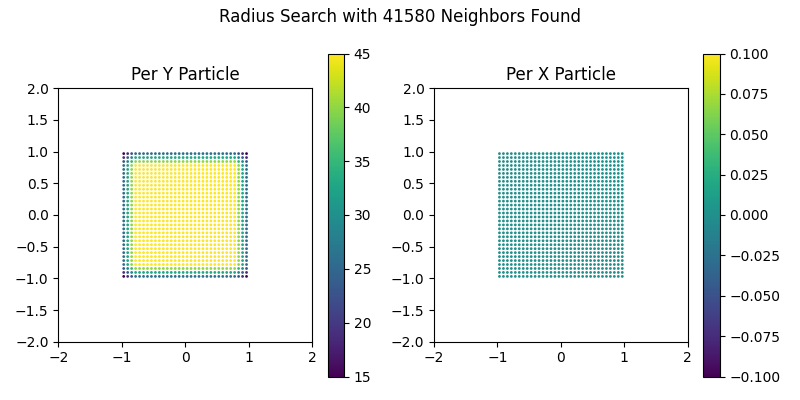

In [20]:
ii, ni_ = torch.unique(i, return_counts = True)
ni = torch.zeros(x.shape[0], dtype = torch.int64, device = x.device)
ni[ii] = ni_
jj, nj_ = torch.unique(j, return_counts = True)
nj = torch.zeros(y.shape[0], dtype = torch.int64, device = x.device)
nj[jj] = nj_

fig, axis = plt.subplots(1,2, figsize = (8,4), squeeze=False)
sc = axis[0,0].scatter(y[:,0].cpu(), y[:,1].cpu(), s = 1, c = ni.cpu().numpy())
axis[0,0].set_aspect('equal')
axis[0,0].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,0].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,0].set_title('Per Y Particle')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(x[:,0].cpu(), x[:,1].cpu(), s = 1, c = adjacencyCH.numNeighbors.cpu().numpy() - ni.cpu().numpy())
axis[0,1].set_aspect('equal')
axis[0,1].set_xlim(domainDescription.min[0].cpu().item(), domainDescription.max[0].cpu().item())
axis[0,1].set_ylim(domainDescription.min[1].cpu().item(), domainDescription.max[1].cpu().item())
axis[0,1].set_title('Per X Particle')

fig.colorbar(sc, ax = axis[0,1])

fig.suptitle(f'Radius Search with {i.shape[0]} Neighbors Found')
fig.tight_layout()

In [21]:
# Given two points in a periodic space [l , r] using minimum image convention, calculate the distance between them
# note that the points could be in any periodic image and not necessarily in the same one or even adjacent ones

@torch.jit.script
def mod(x, min : float, max : float):
    h = max - min
    return ((x + h / 2.0) - torch.floor((x + h / 2.0) / h) * h) - h / 2.0
def moduloDistance(xij, periodicity, min, max):
    if isinstance(periodicity, bool):
        periodicity = [periodicity] * xij.shape[-1]
    return torch.stack([xij[:,i] if not periodic else mod(xij[:,i], min[i], max[i]) for i, periodic in enumerate(periodicity)], dim = -1)

def minimumImageDistance(x, y, periodicity, min, max):
    x_projected = torch.stack([x[:,i] if not periodic else torch.remainder(x[:,i] - min[i], max[i] - min[i]) + min[i] for i, periodic in enumerate(periodicity)], dim = 1)
    y_projected = torch.stack([y[:,i] if not periodic else torch.remainder(y[:,i] - min[i], max[i] - min[i]) + min[i] for i, periodic in enumerate(periodicity)], dim = 1)
    xij = x_projected - y_projected
    return moduloDistance(xij.view(-1, x.shape[1]), periodicity, min, max)

imageDistance = minimumImageDistance(x - offset + 16, y + offset * 17, periodicity, domain.min, domain.max)
print(f"Minimum image distance shape: {imageDistance.shape}")
print(f'Minimum image distance min: {imageDistance.min()}, max: {imageDistance.max()}')

Minimum image distance shape: torch.Size([1024, 2])
Minimum image distance min: 0.0, max: 0.0


In [22]:
from warp.types import vector

@wp.func
def safe_sqrt(x: float):
    return wp.sqrt(x)
@wp.func_grad(safe_sqrt)
def adj_safe_sqrt(x: float, adj_ret: float):
    if x > 0.0:
        wp.adjoint[x] += 1.0 / (2.0 * wp.sqrt(x)) * adj_ret

@wp.func 
def mod_warp(x : wp.float32, min: wp.float32, max: wp.float32):
    h = max - min
    return ((x + h / 2.0) - wp.floor((x + h / 2.0) / h) * h) - h / 2.0

@wp.func
def project_mod(x : wp.float32, min: wp.float32, max: wp.float32):
    # return torch.remainder(x - min, max - min) + min
    # we need to implement this manually because torch.remainder does not work in warp and warp has no remainder
    h = max - min
    return x - h * wp.floor((x - min) / h)

@wp.func
def moduloDistanceComponent(
    x: wp.float32, y: wp.float32, periodic: bool, min: wp.float32, max: wp.float32
):
    if periodic:
        x_projected = project_mod(x, min, max)
        y_projected = project_mod(y, min, max)
        xij = x_projected - y_projected
        return mod_warp(xij, min, max)
    else:
        return x - y

from typing import Any
@wp.func
def minimumImageDistance(
    x: vector(dtype=wp.float32, length=Any),
    y: vector(dtype=wp.float32, length=Any),
    periodicity: wp.array(dtype=wp.bool),
    min: wp.array(dtype=wp.float32),
    max: wp.array(dtype=wp.float32),
    D: wp.int32
):
    retVal = wp.vector(0.0, length = x.length, dtype = wp.float32)
    for i in range(D):
        retVal[i] = moduloDistanceComponent(x[i], y[i], periodicity[i], min[i], max[i])
    return retVal
    
    
    # return wp.vector(
    #     [moduloDistanceComponent(x[i], y[i], periodicity[i], min[i], max[i]) for i in range(x.length)],
    #     dtype=wp.float32
    # )
    
@wp.func
def computeDistance(
    x: vector(dtype=wp.float32, length=Any),
    y: vector(dtype=wp.float32, length=Any),
    periodicity: wp.array(dtype=wp.bool),
    min: wp.array(dtype=wp.float32),
    max: wp.array(dtype=wp.float32)
):
    distVec = minimumImageDistance(x, y, periodicity, min, max, wp.int32(x.length))
    # distVec = x-y
    return safe_sqrt(wp.dot(distVec, distVec))

# @wp.func 
# def computeDistance(x: vector(dtype = wp.float32), y: vector(dtype = wp.float32), periodicity: wp.array(dtype = wp.bool), min: wp.array(dtype = wp.float32), max: wp.array(dtype = wp.float32)):
#     vectorDistance = minimumImageDistanceWarp(x, y, periodicity, min, max)
#     length = wp.sqrt(wp.sum(vectorDistance * vectorDistance))
#     return length

In [23]:
@wp.func
def computePairwiseSupport(hx: wp.float32, hy: wp.float32, mode: wp.uint32):
    if mode == 0: # gather
        return hx
    elif mode == 1: # scatter
        return hy
    elif mode == 2: # symmetric
        return (hx + hy) / 2.0
    elif mode == 3: # superSymmetric
        return wp.max(hx, hy)
    else:
        return hx

In [78]:
@wp.func
def iPow(base: wp.float32, exp: int):
    if exp == 0:
        return 1.0
    elif exp == 1:
        return base
    elif exp == 2:
        return base * base
    elif exp == 3:
        return base * base * base
    elif exp == 4:
        return base * base * base * base
    elif exp == 5:
        return base * base * base * base * base
    elif exp == 6:
        return base * base * base * base * base * base
    else:
        return base**(wp.float32(exp))
    return np.nan

@wp.func
def cpow_warp(q: wp.float32, p: int):
    return iPow(wp.clamp(q, 0.0, 1.0),p)

@wp.func
def k(q: wp.float32, dim: int = 2):
    if dim == 1:
        return cpow_warp(1.0 - q, 5) * (1.0 + 5.0 * q + 8.0 * iPow(q, 2))
    else:
        return cpow_warp(1.0 - q, 6) * (1.0 + 6.0 * q + (35.0 / 3.0) * iPow(q, 2))
    
@wp.func
def C_d(dim: int):
    if dim == 1:
        return 3.0 / 2.0
    elif dim == 2:
        return 9.0 / np.pi
    else:
        return 495.0 / (32.0 * np.pi)

@wp.func
def wendland4_2d(
    r: wp.float32,
    h: wp.float32,
    dim: int = 2
):
    return k(r / h, dim) * C_d(dim) / iPow(h, dim)

In [79]:
@wp.func
def computeDensityWarp(
    xi : vector(dtype = wp.float32, length=Any), hi : wp.float32, mi: wp.float32,
    referencePositions : wp.array(dtype=vector(length=Any, dtype = wp.float32)), referenceSupports : wp.array(dtype = wp.float32), referenceMasses: wp.array(dtype = wp.float32),
    periodicity : wp.array(dtype = wp.bool), domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32),
    mode_uint: wp.uint32,
    
    
    neighborList: wp.array(dtype = wp.int64), 
    neighborOffset : wp.int64, numNeighs: wp.int32,
):
    rho = wp.float32(0.0)
    # pairwiseDistance = computeDistance(xi, xi, periodicity, domainMin, domainMax)
    # pairwiseSupport = computePairwiseSupport(hi, hi, mode_uint)
    # rho = mi * ( 1.0 - pairwiseDistance) #wendland4_2d(pairwiseDistance, pairwiseSupport, 2)
    
    for neighborIndex in range(numNeighs):
        j = wp.int32(neighborList[neighborOffset + wp.int64(neighborIndex)])
        
        
        xj= referencePositions[j]
        hj= referenceSupports[j]
        
        pairwiseDistance = computeDistance(xi, xj, periodicity, domainMin, domainMax)
        pairwiseSupport = computePairwiseSupport(hi, hj, mode_uint)
        # if pairwiseDistance <= pairwiseSupport:
        rho += referenceMasses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2)
    return rho

@wp.kernel
def sphDensity_warp(
    queryPositions : wp.array(dtype = vector(length=Any, dtype=wp.float32)), referencePositions : wp.array(dtype=vector(length=Any, dtype = wp.float32)),
    querySupports : wp.array(dtype = wp.float32), referenceSupports : wp.array(dtype = wp.float32),
    queryMasses: wp.array(dtype = wp.float32), referenceMasses: wp.array(dtype = wp.float32),
    
    domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), periodicity : wp.array(dtype = wp.bool),
    
    mode_uint: wp.uint32,
    neighborList: wp.array(dtype = wp.int64), neighborListRowOffsets: wp.array(dtype = wp.int64), numNeighbors: wp.array(dtype = wp.int64),
    
    densities : wp.array(dtype = wp.float32)                                                                                                               
                                                                                  
):
    N = queryPositions.shape[0]
    M = referencePositions.shape[0]
    D = queryPositions.dtype._length_
    
    i = wp.tid()
    if i >= N:
        return
    
    xi= queryPositions[i]
    hi= querySupports[i]
    mi = queryMasses[i]
    numNeighs = wp.int32(numNeighbors[i])
    neighborOffset = wp.int64(neighborListRowOffsets[i])
    
    rho = computeDensityWarp(xi, hi, mi, referencePositions, referenceSupports, referenceMasses, periodicity, domainMin, domainMax, mode_uint, neighborList, neighborOffset, numNeighs)
        
    densities[i] = rho
        
    

In [80]:
positions_ = castTorchToWarp(referencePositions)

print(positions_.shape, positions_.dtype, positions_.device)
# right now positions are in [N,d] format as floats, it would be more useful if they were in [N] format as vecds so that we can directly index them in the kernel without needing to do any reshaping or pointer arithmetic
from warp.types import vector

positions_vec = wp.from_torch(referencePositions, dtype = vector(length=2, dtype=wp.float32))
# positions_vec = wp.from_torch(referencePositions, dtype = wp.vec2f)
print(positions_vec.shape, positions_vec.dtype, positions_vec.device)

print(positions_.ptr, positions_vec.ptr)


def castTorchToWarpVec(x_torch):
    """
    Cast a PyTorch tensor to a Warp array of vec2f, ensuring it's on the correct device and has the right dtype.
    """
    # Ensure tensor is contiguous and on the correct device
    x_torch = x_torch.contiguous()
    
    if len(x_torch.shape) != 2:
        raise ValueError("Input tensor must be 2D with shape [N, D]")
    N, D = x_torch.shape
    dtype = wp.from_torch(x_torch).dtype
    return wp.from_torch(x_torch, dtype=vector(length=D, dtype=dtype))
    


(1024, 2) <class 'warp._src.types.float32'> cpu
(1024,) <class 'warp._src.types.vector.<locals>.vec_t'> cpu
94468534642368 94468534642368


In [81]:
wp.config.verify_autograd_array_access = True
wp.config.verbose = True


In [95]:

@wp.kernel
def loss_kernel(x: wp.array(dtype=float), loss: wp.array(dtype=float)):
    tid = wp.tid()
    wp.atomic_add(loss, 0, x[tid])
    
positionsTemp = queryPositions.clone()
positionsTemp.requires_grad = True
positionsTemp.grad = None
    
positions_ = castTorchToWarpVec(positionsTemp)
# positions_.grad = None
# positions_.requires_grad = True

areas = torch.ones(x.shape[0], device = x.device) * dx**dim
densities = wp.zeros(x.shape[0], dtype=wp.float32, device = positions_vec.device, requires_grad=True)

areas_warp = castTorchToWarp(areas)
areas_warp.requires_grad = True
tape =  wp.Tape()
with tape:
    wp.launch(
        sphDensity_warp,
        dim = x.shape[0],
        inputs = [
            positions_, positions_,
            castTorchToWarp(querySupports), castTorchToWarp(referenceSupports),
            areas_warp, areas_warp,
            castTorchToWarp(domainDescription.min), castTorchToWarp(domainDescription.max), castTorchToWarp(domainDescription.periodic),
            wp.uint32(mode_uint),
            castTorchToWarp(adjacency.j), castTorchToWarp(adjacency.edgeOffsets), castTorchToWarp(adjacency.numNeighbors),
            densities
        ],
        device = positions_vec.device
    )
    deviation = (densities - 1.0)**2.0
    deviation.requires_grad = True
    loss = wp.zeros(1, dtype=float, requires_grad=True, device = deviation.device)

    wp.launch(loss_kernel, dim=deviation.shape[0], inputs=[deviation, loss], device = deviation.device)
        
    
print(densities, densities.requires_grad)

print(deviation, deviation.dtype)


[0.5079769  0.68154305 0.71238637 ... 0.71238655 0.6815433  0.50797695] True
[0.24208674 0.10141483 0.0827216  ... 0.08272149 0.10141467 0.24208668] <class 'warp._src.types.float32'>


In [96]:
tape.backward(loss)

# print(deviation.grad, deviation)
# print(densities.grad, densities)
# print(areas_warp.grad, areas_warp)
# print(positions_.grad, positions_)
# print(loss.grad, loss)

In [97]:
densities_torch = wp.to_torch(densities)
print(f"Densities shape: {densities_torch.shape}, dtype: {densities_torch.dtype}, device: {densities_torch.device}")
print(f"Densities min: {densities_torch.min()}, max: {densities_torch.max()}, mean: {densities_torch.mean()}")

deviation = (1-densities_torch)**2
error = torch.sum(deviation)
error.backward()

Densities shape: torch.Size([1024]), dtype: torch.float32, device: cpu
Densities min: 0.5079768896102905, max: 1.0004249811172485, mean: 0.959396243095398


In [98]:
print(densities_torch.grad)
print(positionsTemp.grad)

tensor([-1.9681, -1.2738, -1.1505,  ..., -1.1505, -1.2738, -1.9681])
tensor([[-6.1046, -6.1046],
        [ 0.1369, -5.1247],
        [ 0.7245, -4.1727],
        ...,
        [-0.7245,  4.1727],
        [-0.1369,  5.1247],
        [ 6.1046,  6.1046]])


In [31]:
import diffSPH

In [ ]:
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *

particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = areas, densities = torch.zeros_like(areas))


simulationState = BasicState(
    positions = particles_l.positions,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(referencePositions),
    kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
)

# neighborhood, sparseNeighborhood = buildNeighborhood(simulationState, simulationState, domain, 1.4, 'superSymmetric')
# actualNeighbors = filterNeighborhood(sparseNeighborhood)

from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme


In [66]:
pos = particles_l.positions.clone()
pos.grad = None
pos.requires_grad = True
simulationState.positions = pos

neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.4, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
densities = computeDensity(simulationState,  KernelType.Wendland4, neighbors.get('noghost'), SupportScheme.Gather)
print(f"DiffSPH computed densities min: {densities.min()}, max: {densities.max()}, mean: {densities.mean()}")

error = torch.sum((1-densities)**2)
error.backward()


DiffSPH computed densities min: 0.5079768896102905, max: 1.0004249811172485, mean: 0.959396243095398


In [67]:
pos.grad

tensor([[-6.1046, -6.1046],
        [ 0.1369, -5.1247],
        [ 0.7245, -4.1727],
        ...,
        [-0.7245,  4.1727],
        [-0.1369,  5.1247],
        [ 6.1046,  6.1046]])

In [72]:
grad_diff = wp.to_torch(positions_.grad) - pos.grad
print(f'min difference: {torch.min(grad_diff)}, max difference: {torch.max(grad_diff)}')

min difference: -9.5367431640625e-07, max difference: 1.1920928955078125e-06
